In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv("../data/World Wildlife Species.csv")

In [3]:
df.head()

,Unnamed: 0,Scientifc Name,Common Name,Conservation Status
0,0,Loxodonta africana,African Elephant,NaN
1,1,NaN,African forest elephant,Critically Endangered
2,2,Loxodonta africana africana,African savanna elephant,Endangered
3,3,Lycaon pictus,African Wild Dog,Endangered
4,4,Thunnus alalunga,Albacore Tuna,Near Threatened


In [4]:
df.shape

(97, 4)

In [5]:
df.columns

Index(['Unnamed: 0', 'Scientifc Name', 'Common Name', 'Conservation Status'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Unnamed: 0           97 non-null     int64
 1   Scientifc Name       87 non-null     str  
 2   Common Name          97 non-null     str  
 3   Conservation Status  82 non-null     str  
dtypes: int64(1), str(3)
memory usage: 3.2 KB


In [7]:
df.isnull().sum()

Unnamed: 0              0
Scientifc Name         10
Common Name             0
Conservation Status    15
dtype: int64

In [8]:
df = df.drop(columns=["Unnamed: 0"])

In [9]:
df = df.rename(columns={"Scientifc Name": "Scientific Name"})

In [10]:
df.head()

,Scientific Name,Common Name,Conservation Status
0,Loxodonta africana,African Elephant,NaN
1,NaN,African forest elephant,Critically Endangered
2,Loxodonta africana africana,African savanna elephant,Endangered
3,Lycaon pictus,African Wild Dog,Endangered
4,Thunnus alalunga,Albacore Tuna,Near Threatened


In [11]:
df["Conservation Status"].unique()

<StringArray>
[                    nan, 'Critically Endangered',            'Endangered',
       'Near Threatened',         'Least Concern',            'Vulnerable']
Length: 6, dtype: str

In [12]:
df["Conservation Status"].value_counts()

Conservation Status
Endangered               29
Critically Endangered    17
Vulnerable               16
Least Concern            12
Near Threatened           8
Name: count, dtype: int64

## Distribution of Conservation Status

This analysis explores how species are distributed across conservation status categories in the dataset.

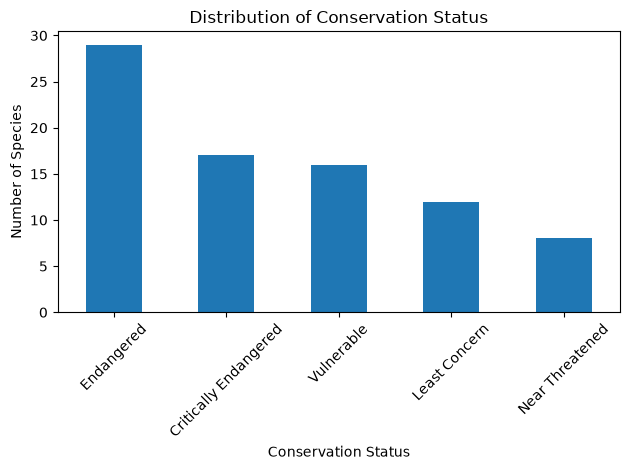

In [13]:
status_counts = df["Conservation Status"].value_counts()

status_counts.plot(kind="bar")

plt.title("Distribution of Conservation Status")
plt.xlabel("Conservation Status")
plt.ylabel("Number of Species")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

Endangered species are the most represented group in the dataset, with 29 species, followed by Critically Endangered species with 17 and Vulnerable species with 16.

Least Concern and Near Threatened species are less represented in this dataset.

This distribution describes the composition of the dataset and should not be interpreted as the global distribution of species conservation status.

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["Scientific Name"].nunique()

86

In [16]:
df.shape

(97, 3)

In [17]:
df["Conservation Status"].isnull().sum()

np.int64(15)

In [18]:
df["Conservation Status"].value_counts(dropna=False)

Conservation Status
Endangered               29
Critically Endangered    17
Vulnerable               16
NaN                      15
Least Concern            12
Near Threatened           8
Name: count, dtype: int64

In [19]:
df["Scientific Name"].isnull().sum()

np.int64(10)

In [20]:
df[df["Conservation Status"].isnull()]

,Scientific Name,Common Name,Conservation Status
0,Loxodonta africana,African Elephant,NaN
5,Scientific Name Inia geoffrensis,Amazon River Dolphin,NaN
24,Panthera tigris tigris,Continental Tiger,NaN
26,NaN,Dolphins and Porpoises,NaN
29,NaN,Elephant,NaN
35,Gorilla gorilla and Gorilla beringei,Gorilla,NaN
62,NaN,Pacific Salmon,NaN
63,NaN,Pangolin,NaN
64,Spheniscidae,Penguin,NaN
66,Dendrobates species,Poison Dart Frog,NaN


In [21]:
df[df["Scientific Name"].isnull()]

,Scientific Name,Common Name,Conservation Status
1,NaN,African forest elephant,Critically Endangered
26,NaN,Dolphins and Porpoises,NaN
29,NaN,Elephant,NaN
34,NaN,Giant Tortoise,Vulnerable
62,NaN,Pacific Salmon,NaN
63,NaN,Pangolin,NaN
70,NaN,Rhino,NaN
74,NaN,Seals,NaN
76,NaN,Shark,NaN
78,NaN,Sloth,NaN


In [22]:
df[
    df["Conservation Status"].isnull() &
    df["Scientific Name"].isnull()
]

,Scientific Name,Common Name,Conservation Status
26,NaN,Dolphins and Porpoises,NaN
29,NaN,Elephant,NaN
62,NaN,Pacific Salmon,NaN
63,NaN,Pangolin,NaN
70,NaN,Rhino,NaN
74,NaN,Seals,NaN
76,NaN,Shark,NaN
78,NaN,Sloth,NaN


## Data Cleaning 

During the initial exploration, missing values were identified in the Scientific Name and Conservation Status columns. These records were inspected before deciding how to handle them.

In [23]:
species_df = df.dropna(
    subset=["Scientific Name", "Conservation Status"]
).copy()

In [24]:
species_df.shape

(80, 3)

In [25]:
species_df.isnull().sum()

Scientific Name        0
Common Name            0
Conservation Status    0
dtype: int64

## Data Cleaning

During the initial exploration, missing values were found in the `Scientific Name` and `Conservation Status` columns.

Some records represent broader animal groups, such as sharks, elephants and dolphins, rather than individual species. Since this analysis focuses on species-level conservation status, records without both a scientific name and conservation status were excluded from the analytical dataset.

The original dataset was preserved in `df`, while the cleaned data was stored in `species_df`.

### Duplicate records

One duplicated scientific name was identified: *Elephas maximus indicus*, appearing under two common names ("Asian Elephant" and "Indian Elephant").

Since this analysis treats the scientific name as the species identifier and both records share the same conservation status, only one occurrence was retained to avoid double counting.

In [26]:
species_df.shape

(80, 3)

In [27]:
species_df["Scientific Name"].nunique()

79

In [28]:
species_df["Conservation Status"].value_counts()

Conservation Status
Endangered               29
Critically Endangered    16
Vulnerable               15
Least Concern            12
Near Threatened           8
Name: count, dtype: int64

In [29]:
species_df[
    species_df["Scientific Name"].duplicated(keep=False)
]

,Scientific Name,Common Name,Conservation Status
9,Elephas maximus indicus,Asian Elephant,Endangered
45,Elephas maximus indicus,Indian Elephant,Endangered


In [30]:
species_df = species_df.drop_duplicates(
    subset=["Scientific Name"],
    keep="first"
).copy()

In [31]:
species_df.shape

(79, 3)

In [32]:
species_df["Scientific Name"].nunique()

79

In [33]:
species_df["Conservation Status"].value_counts()

Conservation Status
Endangered               28
Critically Endangered    16
Vulnerable               15
Least Concern            12
Near Threatened           8
Name: count, dtype: int64

# Exploratory Data Analysis

## 1. Distribution of Conservation Status

The first step is to examine how the species in the cleaned dataset are distributed across conservation status categories.

In [34]:
status_counts = species_df["Conservation Status"].value_counts()

status_counts

Conservation Status
Endangered               28
Critically Endangered    16
Vulnerable               15
Least Concern            12
Near Threatened           8
Name: count, dtype: int64

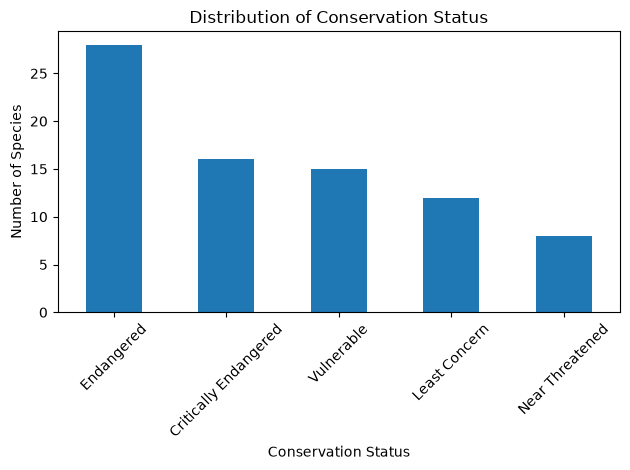

In [35]:
status_counts.plot(kind="bar")

plt.title("Distribution of Conservation Status")
plt.xlabel("Conservation Status")
plt.ylabel("Number of Species")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [36]:
status_percentage = (
    species_df["Conservation Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

status_percentage

Conservation Status
Endangered               35.4
Critically Endangered    20.3
Vulnerable               19.0
Least Concern            15.2
Near Threatened          10.1
Name: proportion, dtype: float64

### Findings

- **Endangered** is the most represented conservation category in the dataset.
- **Critically Endangered** and **Vulnerable** species also represent a substantial portion of the records.
- **Least Concern** and **Near Threatened** species are less represented.

These results describe the composition of this specific dataset and should not be interpreted as the global distribution of species conservation status.

# Conclusion

This exploratory analysis examined the distribution of conservation status among species in the dataset.

After cleaning the data, 79 unique records with both scientific names and conservation status were retained for analysis.

Endangered species were the most represented category, accounting for approximately 35.4% of the cleaned dataset. Critically Endangered and Vulnerable species were also strongly represented.

These findings reflect the composition of this specific dataset and should not be interpreted as estimates of the global distribution of threatened species.

## Limitations

The dataset contains limited biological and ecological information, which restricts the types of relationships that can be investigated.

Future analyses could incorporate variables such as habitat, geographic distribution, population size, taxonomic group, and population trends.

In [37]:
plt.savefig(
    "../images/conservation_status_distribution.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>